<a href="https://colab.research.google.com/github/oumaimabelgaied/GNN_fraud_detection/blob/main/baseline_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Baseline Models — Elliptic Bitcoin Dataset
## Random Forest & XGBoost — Fair Comparison with GCN
### Training A (Random Split) · Training B (Chronological Split)

This notebook mirrors the **exact evaluation protocol** used in the GCN notebook:
- Same preprocessing pipeline (imputation → deduplication → RobustScaler)
- **Training A**: random 70 / 30 stratified split (same as GCN Training A)
- **Training B**: chronological split — time steps 1-34 train, 35-49 test (same as GCN Training B)
- Identical metrics: Precision · Recall · F1 (illicit class) · ROC-AUC · PR-AUC
- Per-time-step F1 evolution plot (same as GCN)
- Final summary table for direct comparison


## 1 · Mount Drive & Install Dependencies

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Install imbalanced-learn if not already present
!pip install imbalanced-learn -q


## 2 · Load Raw Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

BASE_PATH = "/content/drive/MyDrive/PFART4/"
BASE_PATH_TX = BASE_PATH + "Elliptic++ Dataset/"

# Load txs_classes first
tx_classes  = pd.read_csv(BASE_PATH_TX + "txs_classes.csv")

# Load txs_features.csv, letting pandas infer the header
tx_features = pd.read_csv(BASE_PATH_TX + "txs_features.csv")

# Rename 'Time step' column to 'time_step'
if 'Time step' in tx_features.columns:
    tx_features = tx_features.rename(columns={'Time step': 'time_step'})

# Dynamically rename Local_feature_X and Agg_feature_X to feature_X
new_feature_names = {}
for col in tx_features.columns:
    if col.startswith('Local_feature_'):
        num = col.split('_')[2]
        new_feature_names[col] = f'feature_{num}'
    elif col.startswith('Agg_feature_'):
        num = col.split('_')[2]
        new_feature_names[col] = f'feature_{num}'
tx_features = tx_features.rename(columns=new_feature_names)

# Ensure txId is numeric in both DataFrames before merge
tx_features['txId'] = pd.to_numeric(tx_features['txId'], errors='coerce')
tx_features = tx_features.dropna(subset=['txId']) # Drop rows where txId became NaN (e.g., if a header row snuck in)
tx_classes['txId'] = pd.to_numeric(tx_classes['txId'], errors='coerce')
tx_classes = tx_classes.dropna(subset=['txId'])

# Merge tx_features and tx_classes
tx_data = pd.merge(tx_features, tx_classes, on="txId", how="inner")

# Identify actual feature columns by checking column names directly
global feature_cols_raw # Declare as global to be accessible in other cells
feature_cols_raw = [col for col in tx_data.columns if col.startswith('feature_')]

# Ensure feature columns are numeric
for col in feature_cols_raw:
    tx_data[col] = pd.to_numeric(tx_data[col], errors='coerce')

# Drop any rows that might have non-numeric feature data after coercion
# (e.g., if an entire feature column was non-numeric, it would be all NaNs)
tx_data = tx_data.dropna(subset=feature_cols_raw)


print(f"Dataset shape: {tx_data.shape}")
print(f"Time steps range: {tx_data['time_step'].min()} – {tx_data['time_step'].max()}")
print(f"\nClass distribution (raw):")
print(tx_data['class'].value_counts().rename({1: 'Illicit', 2: 'Licit', 3: 'Unknown'}))
tx_data.head()

Dataset shape: (203769, 185)
Time steps range: 1 – 49

Class distribution (raw):
class
Unknown    157205
Licit       42019
Illicit      4545
Name: count, dtype: int64


,txId,time_step,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,...,in_BTC_max,in_BTC_mean,in_BTC_median,in_BTC_total,out_BTC_min,out_BTC_max,out_BTC_mean,out_BTC_median,out_BTC_total,class
0,3321,1,-0.169615,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.160199,...,0.534072,0.534072,0.534072,0.534072,1.668990e-01,0.367074,0.266986,0.266986,0.533972,3
1,11108,1,-0.137586,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.127429,...,5.611878,5.611878,5.611878,5.611878,5.861940e-01,5.025584,2.805889,2.805889,5.611778,3
2,51816,1,-0.170103,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.160699,...,0.456608,0.456608,0.456608,0.456608,2.279902e-01,0.228518,0.228254,0.228254,0.456508,3
3,68869,1,-0.114267,-0.184668,-1.201369,0.028105,-0.043875,-0.113002,0.547008,-0.161652,...,8.000000,3.102967,1.000000,9.308900,1.229000e+00,8.079800,4.654400,4.654400,9.308800,2
4,89273,1,5.202107,-0.210553,-1.756361,-0.121970,260.090707,-0.113002,-0.061584,5.335864,...,852.164680,852.164680,852.164680,852.164680,1.300000e-07,41.264036,0.065016,0.000441,852.164680,2


## 3 · Exploratory Data Analysis

=== GLOBAL DATA QUALITY ===
Total rows : 203,769
Total cols : 185
Missing values: 16405


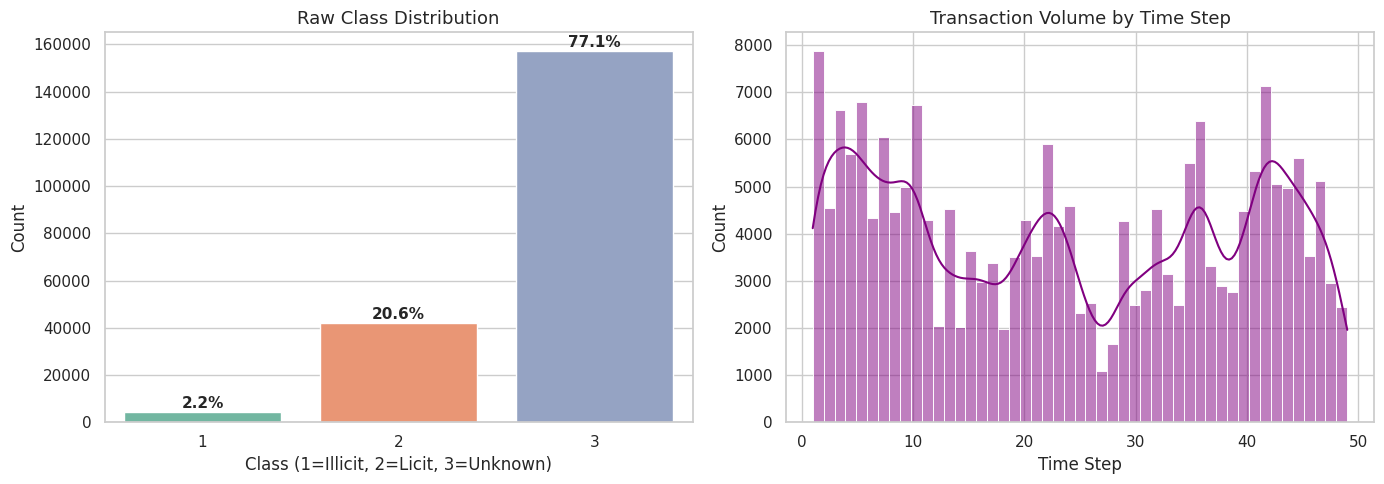

In [ ]:
print("=== GLOBAL DATA QUALITY ===")
print(f"Total rows : {tx_data.shape[0]:,}")
print(f"Total cols : {tx_data.shape[1]}")
print(f"Missing values: {tx_data.isnull().sum().sum()}")

# Class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = sns.countplot(data=tx_data, x='class', palette='Set2', ax=axes[0])
axes[0].set_title("Raw Class Distribution", fontsize=13)
axes[0].set_xlabel("Class (1=Illicit, 2=Licit, 3=Unknown)")
axes[0].set_ylabel("Count")
total = len(tx_data)
for p in ax.patches:
    axes[0].annotate(f'{100*p.get_height()/total:.1f}%',
                     (p.get_x() + p.get_width()/2, p.get_height() + 1500),
                     ha='center', fontsize=11, fontweight='bold')

sns.histplot(data=tx_data, x='time_step', bins=49, kde=True, color='purple', ax=axes[1])
axes[1].set_title("Transaction Volume by Time Step", fontsize=13)
axes[1].set_xlabel("Time Step")
axes[1].set_ylabel("Count")
plt.tight_layout()
plt.show()


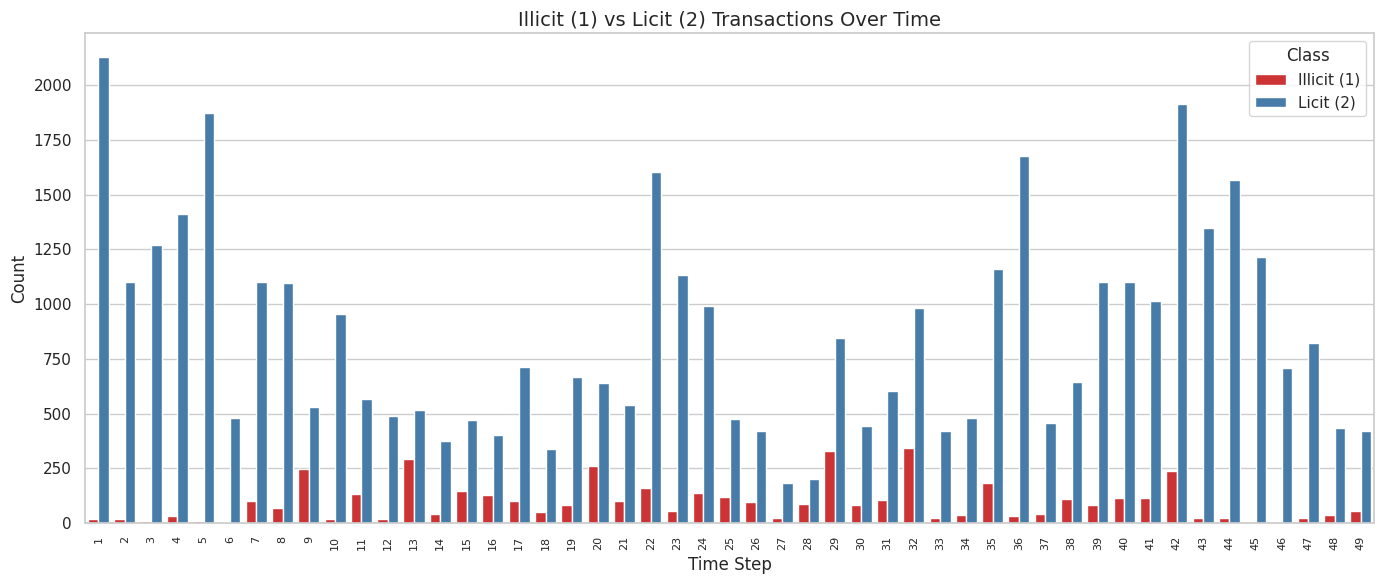

In [ ]:
# Fraud vs Licit evolution over time
plt.figure(figsize=(14, 6))
sns.countplot(data=tx_data[tx_data['class'] != 3], x='time_step', hue='class', palette='Set1')
plt.title("Illicit (1) vs Licit (2) Transactions Over Time", fontsize=14)
plt.xlabel("Time Step"); plt.ylabel("Count")
plt.legend(title="Class", labels=['Illicit (1)', 'Licit (2)'])
plt.xticks(rotation=90, fontsize=8)
plt.tight_layout()
plt.show()


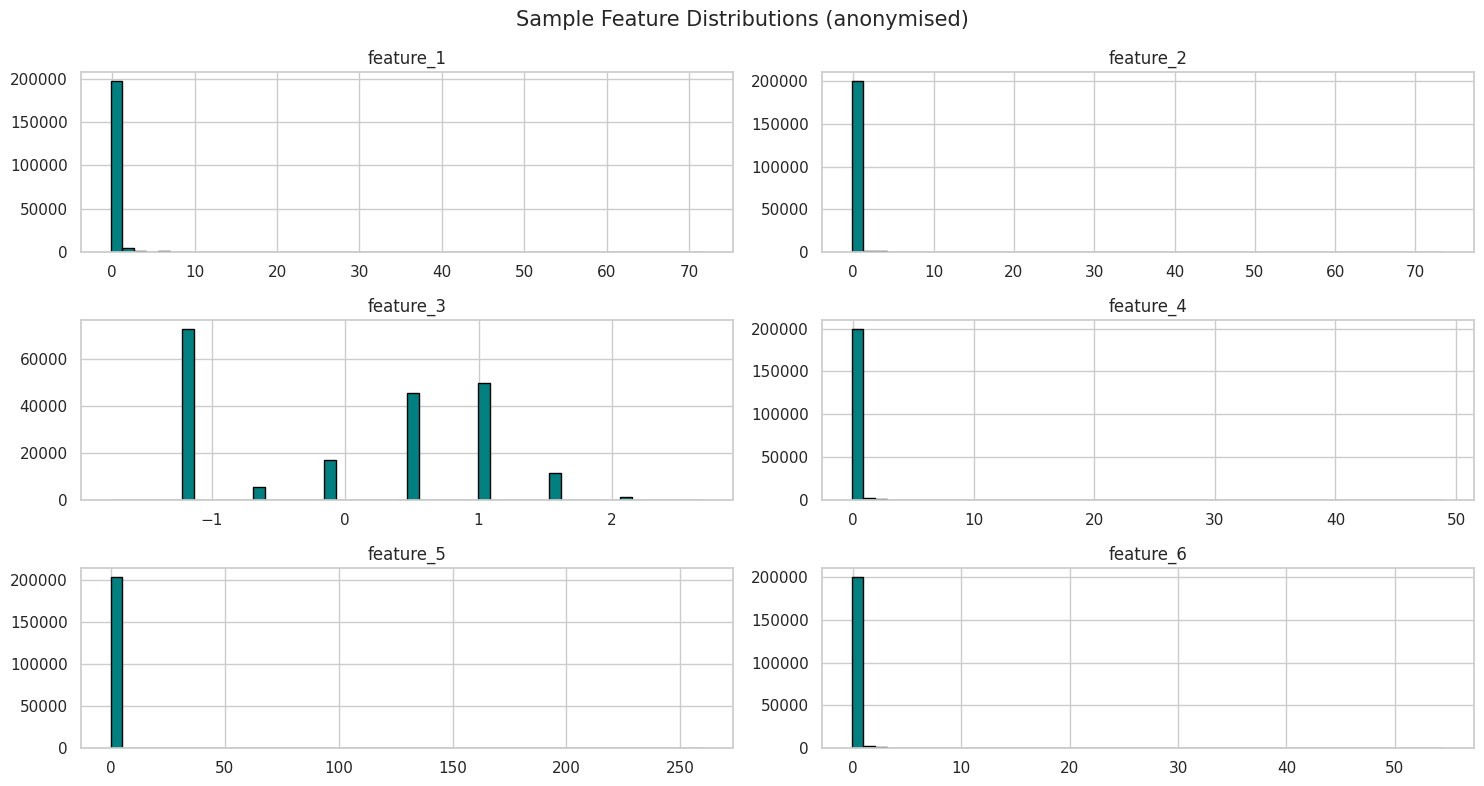

In [ ]:
# Feature distribution sample
feature_cols_raw = [f'feature_{i}' for i in range(1, tx_data.shape[1]-2)]
sample_feats = feature_cols_raw[:6]
tx_data[sample_feats].hist(figsize=(15, 8), bins=50, color='teal', edgecolor='black')
plt.suptitle("Sample Feature Distributions (anonymised)", fontsize=15)
plt.tight_layout()
plt.show()


Local features     : 93
Aggregated features: 0


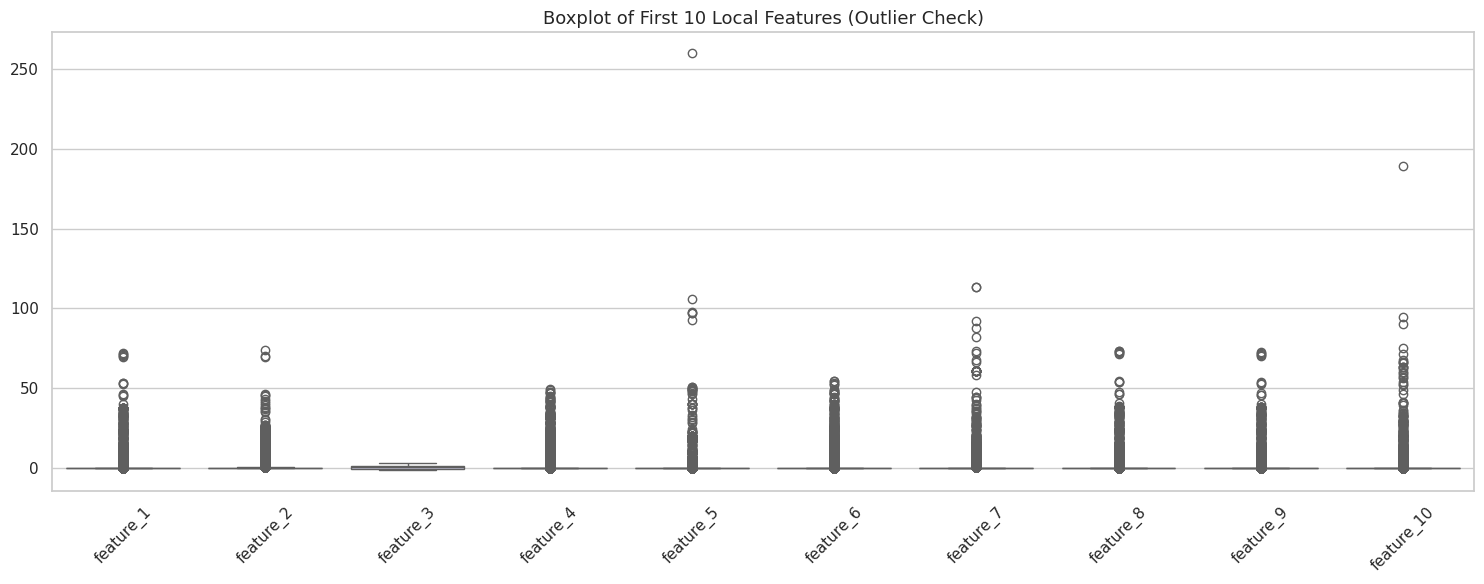

In [ ]:
# Local vs Aggregated feature counts
local_features = [f'feature_{i}' for i in range(1, 94)  if f'feature_{i}' in tx_data.columns]
agg_features   = [f'feature_{i}' for i in range(94, 167) if f'feature_{i}' in tx_data.columns]
print(f"Local features     : {len(local_features)}")
print(f"Aggregated features: {len(agg_features)}")

# Outlier check — first 10 local features
plt.figure(figsize=(15, 6))
sns.boxplot(data=tx_data[local_features[:10]], palette="Set3")
plt.title("Boxplot of First 10 Local Features (Outlier Check)", fontsize=13)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
# PCA 2-D projection: Licit vs Illicit
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

labeled_raw = tx_data[tx_data['class'] != 3].copy()
X_viz = labeled_raw[feature_cols_raw].fillna(0)
y_viz = labeled_raw['class']

scaler_viz = StandardScaler()
X_scaled_viz = scaler_viz.fit_transform(X_viz)

pca_viz = PCA(n_components=2)
X_pca = pca_viz.fit_transform(X_scaled_viz)

plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y_viz,
                palette={1: 'red', 2: 'blue'}, alpha=0.4, s=12)
plt.title("PCA 2-D Projection: Licit vs Illicit", fontsize=14)
plt.xlabel(f"PC1 ({pca_viz.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca_viz.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.legend(title="Class", labels=['Illicit (1)', 'Licit (2)'])
plt.tight_layout()
plt.show()


KeyError: "['feature_94', 'feature_95', 'feature_96', 'feature_97', 'feature_98', 'feature_99', 'feature_100', 'feature_101', 'feature_102', 'feature_103', 'feature_104', 'feature_105', 'feature_106', 'feature_107', 'feature_108', 'feature_109', 'feature_110', 'feature_111', 'feature_112', 'feature_113', 'feature_114', 'feature_115', 'feature_116', 'feature_117', 'feature_118', 'feature_119', 'feature_120', 'feature_121', 'feature_122', 'feature_123', 'feature_124', 'feature_125', 'feature_126', 'feature_127', 'feature_128', 'feature_129', 'feature_130', 'feature_131', 'feature_132', 'feature_133', 'feature_134', 'feature_135', 'feature_136', 'feature_137', 'feature_138', 'feature_139', 'feature_140', 'feature_141', 'feature_142', 'feature_143', 'feature_144', 'feature_145', 'feature_146', 'feature_147', 'feature_148', 'feature_149', 'feature_150', 'feature_151', 'feature_152', 'feature_153', 'feature_154', 'feature_155', 'feature_156', 'feature_157', 'feature_158', 'feature_159', 'fea

## 4 · Preprocessing Pipeline
*(Identical pipeline applied before both Training A and Training B)*

STEP 1 ✓  Features renamed (local_1..93, agg_94..166)
STEP 2 ✓  Dropped 157,205 Unknown rows → 46,564 labeled transactions


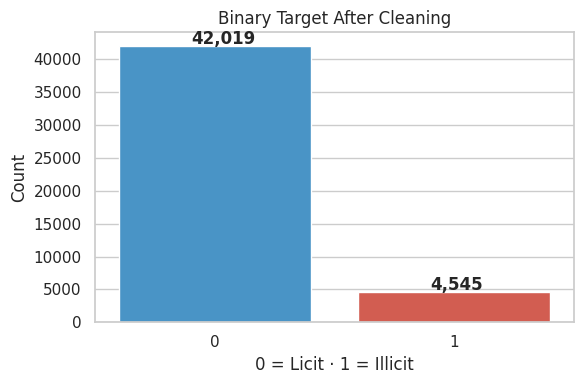

STEP 3 ✓  Imputed 0 NaNs with column medians
STEP 4 ✓  Dropped 11 redundant features → 82 remain


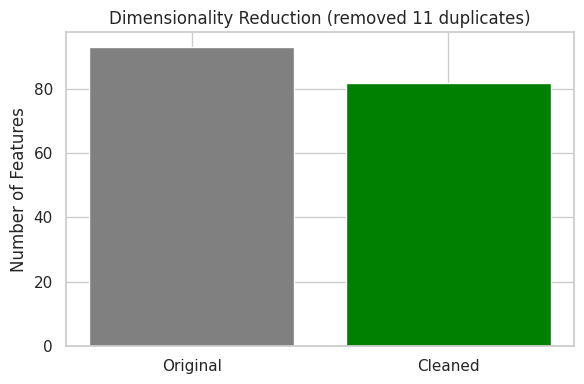

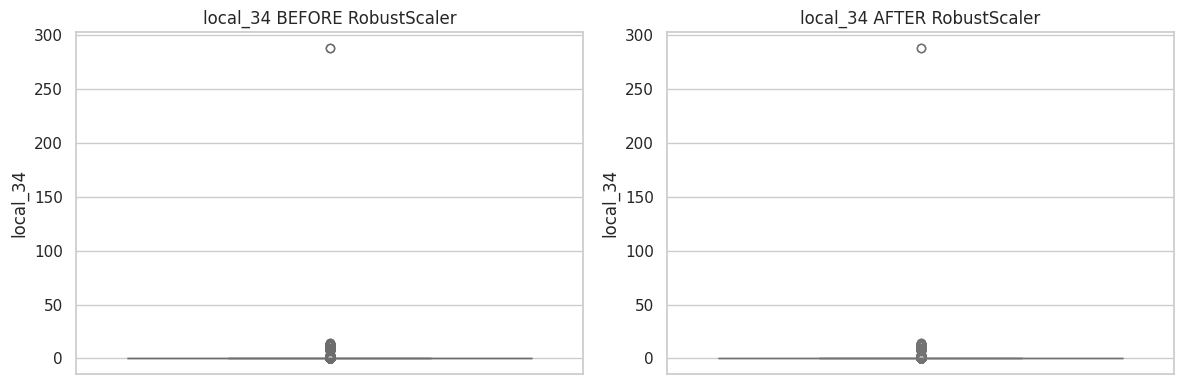


STEP 5 ✓  RobustScaler applied
STEP 6    Class imbalance: 9.76% Illicit / 90.24% Licit
          ⚠ Severe imbalance → SMOTE will be applied to training sets only

Final feature matrix shape : (46564, 82)
Final label vector shape   : (46564,)


In [ ]:
from sklearn.preprocessing import RobustScaler

tx_clean = tx_data.copy()

# ── STEP 1: Rename features ──────────────────────────────────────────────────
rename_dict = {}
for i in range(1, 94):
    rename_dict[f'feature_{i}'] = f'local_{i}'
for i in range(94, 167):
    rename_dict[f'feature_{i}'] = f'agg_{i}'
tx_clean = tx_clean.rename(columns=rename_dict)
print("STEP 1 ✓  Features renamed (local_1..93, agg_94..166)")

# ── STEP 2: Remove Unknown class, binarise ────────────────────────────────────
initial_rows = len(tx_clean)
tx_clean = tx_clean[tx_clean['class'] != 3].copy()
tx_clean['class'] = tx_clean['class'].map({1: 1, 2: 0})
tx_clean = tx_clean.reset_index(drop=True)
print(f"STEP 2 ✓  Dropped {initial_rows - len(tx_clean):,} Unknown rows → {len(tx_clean):,} labeled transactions")

fig, ax = plt.subplots(figsize=(6, 4))
bar = sns.countplot(data=tx_clean, x='class', hue='class',
                    palette=['#3498db', '#e74c3c'], legend=False, ax=ax)
ax.set_title("Binary Target After Cleaning", fontsize=12)
ax.set_xlabel("0 = Licit · 1 = Illicit")
ax.set_ylabel("Count")
for p in bar.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + 0.3, p.get_height() + 300), fontweight='bold')
plt.tight_layout(); plt.show()

# ── STEP 3: Type coercion & median imputation ────────────────────────────────
feature_cols = [c for c in tx_clean.columns if c.startswith('local_') or c.startswith('agg_')]
tx_clean[feature_cols] = tx_clean[feature_cols].apply(pd.to_numeric, errors='coerce')
missing_before = tx_clean[feature_cols].isnull().sum().sum()
tx_clean[feature_cols] = tx_clean[feature_cols].fillna(tx_clean[feature_cols].median())
print(f"STEP 3 ✓  Imputed {missing_before} NaNs with column medians")

# ── STEP 4: Drop near-perfectly correlated features (r ≥ 0.999) ─────────────
corr_matrix = tx_clean[feature_cols].corr().abs()
upper       = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop     = [col for col in upper.columns if any(upper[col] >= 0.999)]
tx_clean    = tx_clean.drop(columns=to_drop)
feature_cols_clean = [c for c in tx_clean.columns if c.startswith('local_') or c.startswith('agg_')]
print(f"STEP 4 ✓  Dropped {len(to_drop)} redundant features → {len(feature_cols_clean)} remain")

plt.figure(figsize=(6, 4))
plt.bar(['Original', 'Cleaned'], [len(feature_cols), len(feature_cols_clean)], color=['gray', 'green'])
plt.title(f"Dimensionality Reduction (removed {len(to_drop)} duplicates)")
plt.ylabel("Number of Features")
plt.tight_layout(); plt.show()

# ── STEP 5: RobustScaler ────────────────────────────────────────────────────
skewed_feat = 'local_34'
before_scaling = tx_clean[skewed_feat].copy()

scaler = RobustScaler()
tx_clean[feature_cols_clean] = scaler.fit_transform(tx_clean[feature_cols_clean])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(y=before_scaling,          ax=axes[0], color='salmon')
axes[0].set_title(f"{skewed_feat} BEFORE RobustScaler")
sns.boxplot(y=tx_clean[skewed_feat],   ax=axes[1], color='lightgreen')
axes[1].set_title(f"{skewed_feat} AFTER RobustScaler")
plt.tight_layout(); plt.show()

# ── STEP 6: Imbalance report ────────────────────────────────────────────────
illicit_ratio = tx_clean['class'].mean() * 100
print(f"\nSTEP 5 ✓  RobustScaler applied")
print(f"STEP 6    Class imbalance: {illicit_ratio:.2f}% Illicit / {100-illicit_ratio:.2f}% Licit")
if illicit_ratio < 20:
    print("          ⚠ Severe imbalance → SMOTE will be applied to training sets only")

X_all = tx_clean[feature_cols_clean].copy()
y_all = tx_clean['class'].copy()
print(f"\nFinal feature matrix shape : {X_all.shape}")
print(f"Final label vector shape   : {y_all.shape}")


## 5 · Shared Evaluation Helpers
*(Mirror of the GCN notebook's evaluation functions)*

In [ ]:
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score,
    f1_score
)
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_model(name, y_true, y_pred, y_prob, color):
    """Print classification report + return metric dict."""
    print(f"\n{'='*55}")
    print(f"  {name}")
    print('='*55)
    print(classification_report(y_true, y_pred, target_names=['Licit (0)', 'Illicit (1)'], digits=4))
    auc  = roc_auc_score(y_true, y_prob)
    ap   = average_precision_score(y_true, y_prob)
    f1_i = f1_score(y_true, y_pred)
    p_i  = classification_report(y_true, y_pred, output_dict=True)['1']['precision']
    r_i  = classification_report(y_true, y_pred, output_dict=True)['1']['recall']
    print(f"  ROC-AUC  : {auc:.4f}  |  PR-AUC : {ap:.4f}")
    return {'model': name, 'Precision_Illicit': p_i, 'Recall_Illicit': r_i,
            'F1_Illicit': f1_i, 'ROC_AUC': auc, 'PR_AUC': ap}


def plot_evaluation_panel(results, title_prefix):
    """4-panel: 2 confusion matrices + ROC + PR curve."""
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle(f'Evaluation Panel — {title_prefix}', fontsize=16, fontweight='bold')

    colors  = ['Blues', 'Oranges']
    palettes = ['blue', 'darkorange']

    for idx, r in enumerate(results):
        cm = confusion_matrix(r['y_true'], r['y_pred'])
        sns.heatmap(cm, annot=True, fmt='d', cmap=colors[idx],
                    xticklabels=['Licit', 'Illicit'],
                    yticklabels=['Licit', 'Illicit'], ax=axes[0, idx])
        axes[0, idx].set_title(f'Confusion Matrix: {r["name"]}', fontsize=13)
        axes[0, idx].set_xlabel('Predicted'); axes[0, idx].set_ylabel('True')

    # ROC
    for idx, r in enumerate(results):
        fpr, tpr, _ = roc_curve(r['y_true'], r['y_prob'])
        auc = roc_auc_score(r['y_true'], r['y_prob'])
        axes[1, 0].plot(fpr, tpr, color=palettes[idx],
                        label=f'{r["name"]} (AUC={auc:.3f})')
    axes[1, 0].plot([0,1],[0,1],'k--', label='Random')
    axes[1, 0].set_title('ROC Curve Comparison', fontsize=13)
    axes[1, 0].set_xlabel('False Positive Rate'); axes[1, 0].set_ylabel('True Positive Rate')
    axes[1, 0].legend(); axes[1, 0].grid(alpha=0.3)

    # PR
    for idx, r in enumerate(results):
        prec, rec, _ = precision_recall_curve(r['y_true'], r['y_prob'])
        ap = average_precision_score(r['y_true'], r['y_prob'])
        axes[1, 1].plot(rec, prec, color=palettes[idx],
                        label=f'{r["name"]} (AP={ap:.3f})')
    axes[1, 1].set_title('Precision-Recall Curve Comparison', fontsize=13)
    axes[1, 1].set_xlabel('Recall'); axes[1, 1].set_ylabel('Precision')
    axes[1, 1].legend(); axes[1, 1].grid(alpha=0.3)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


def plot_f1_per_timestep(model, X_df, y_df, time_df, model_name, color):
    """Compute illicit-class F1 per time step and plot — mirrors GCN evaluation."""
    steps = sorted(time_df.unique())
    f1s = []
    for ts in steps:
        mask = time_df == ts
        if mask.sum() == 0 or y_df[mask].sum() == 0:
            f1s.append(np.nan)
            continue
        preds = model.predict(X_df[mask])
        f1s.append(f1_score(y_df[mask], preds, zero_division=0))

    plt.figure(figsize=(14, 5))
    plt.plot(steps, f1s, marker='o', color=color, linewidth=2, label=model_name)
    plt.axvline(x=34.5, color='red', linestyle='--', linewidth=1.5, label='Train/Test boundary (step 34)')
    plt.title(f'Illicit F1-Score per Time Step — {model_name}', fontsize=14)
    plt.xlabel('Time Step'); plt.ylabel('F1 Score (Illicit class)')
    plt.ylim(0, 1.05); plt.legend(); plt.grid(alpha=0.3)
    plt.tight_layout(); plt.show()
    return steps, f1s


## 6 · Training A — Random Stratified Split (70 / 30)
Same protocol as GCN Training A: random split with `random_state=42`, stratified on class label.  
SMOTE applied **only** on the training portion.


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

print("=" * 60)
print("  TRAINING A — Random 70/30 Stratified Split")
print("=" * 60)

# ── Split ────────────────────────────────────────────────────────────────────
X_trainA, X_testA, y_trainA, y_testA = train_test_split(
    X_all, y_all, test_size=0.30, random_state=42, stratify=y_all
)
# Keep time step reference for the test set (for per-step F1)
time_all = tx_clean['time_step'].copy()
_, time_testA = train_test_split(time_all, test_size=0.30, random_state=42, stratify=y_all)

print(f"Train size : {X_trainA.shape[0]:,}  |  Test size : {X_testA.shape[0]:,}")
print(f"Illicit in train : {y_trainA.sum()}  |  Illicit in test : {y_testA.sum()}")

# ── SMOTE on train only ──────────────────────────────────────────────────────
smote = SMOTE(random_state=42)
X_trainA_s, y_trainA_s = smote.fit_resample(X_trainA, y_trainA)
print(f"After SMOTE — Illicit: {y_trainA_s.sum():,}  |  Licit: {(y_trainA_s==0).sum():,}")

# ── Train RF ─────────────────────────────────────────────────────────────────
print("\nTraining Random Forest (Training A)...")
rf_A = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_A.fit(X_trainA_s, y_trainA_s)

# ── Train XGB ────────────────────────────────────────────────────────────────
print("Training XGBoost (Training A)...")
xgb_A = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss', n_jobs=-1, verbosity=0)
xgb_A.fit(X_trainA_s, y_trainA_s)
print("Training A complete ✓")


  TRAINING A — Random 70/30 Stratified Split
Train size : 32,594  |  Test size : 13,970
Illicit in train : 3181  |  Illicit in test : 1364
After SMOTE — Illicit: 29,413  |  Licit: 29,413

Training Random Forest (Training A)...
Training XGBoost (Training A)...
Training A complete ✓



  Random Forest — Training A
              precision    recall  f1-score   support

   Licit (0)     0.9876    0.9949    0.9913     12606
 Illicit (1)     0.9496    0.8849    0.9161      1364

    accuracy                         0.9842     13970
   macro avg     0.9686    0.9399    0.9537     13970
weighted avg     0.9839    0.9842    0.9839     13970

  ROC-AUC  : 0.9938  |  PR-AUC : 0.9683

  XGBoost       — Training A
              precision    recall  f1-score   support

   Licit (0)     0.9898    0.9952    0.9925     12606
 Illicit (1)     0.9537    0.9054    0.9289      1364

    accuracy                         0.9865     13970
   macro avg     0.9717    0.9503    0.9607     13970
weighted avg     0.9863    0.9865    0.9863     13970

  ROC-AUC  : 0.9955  |  PR-AUC : 0.9772


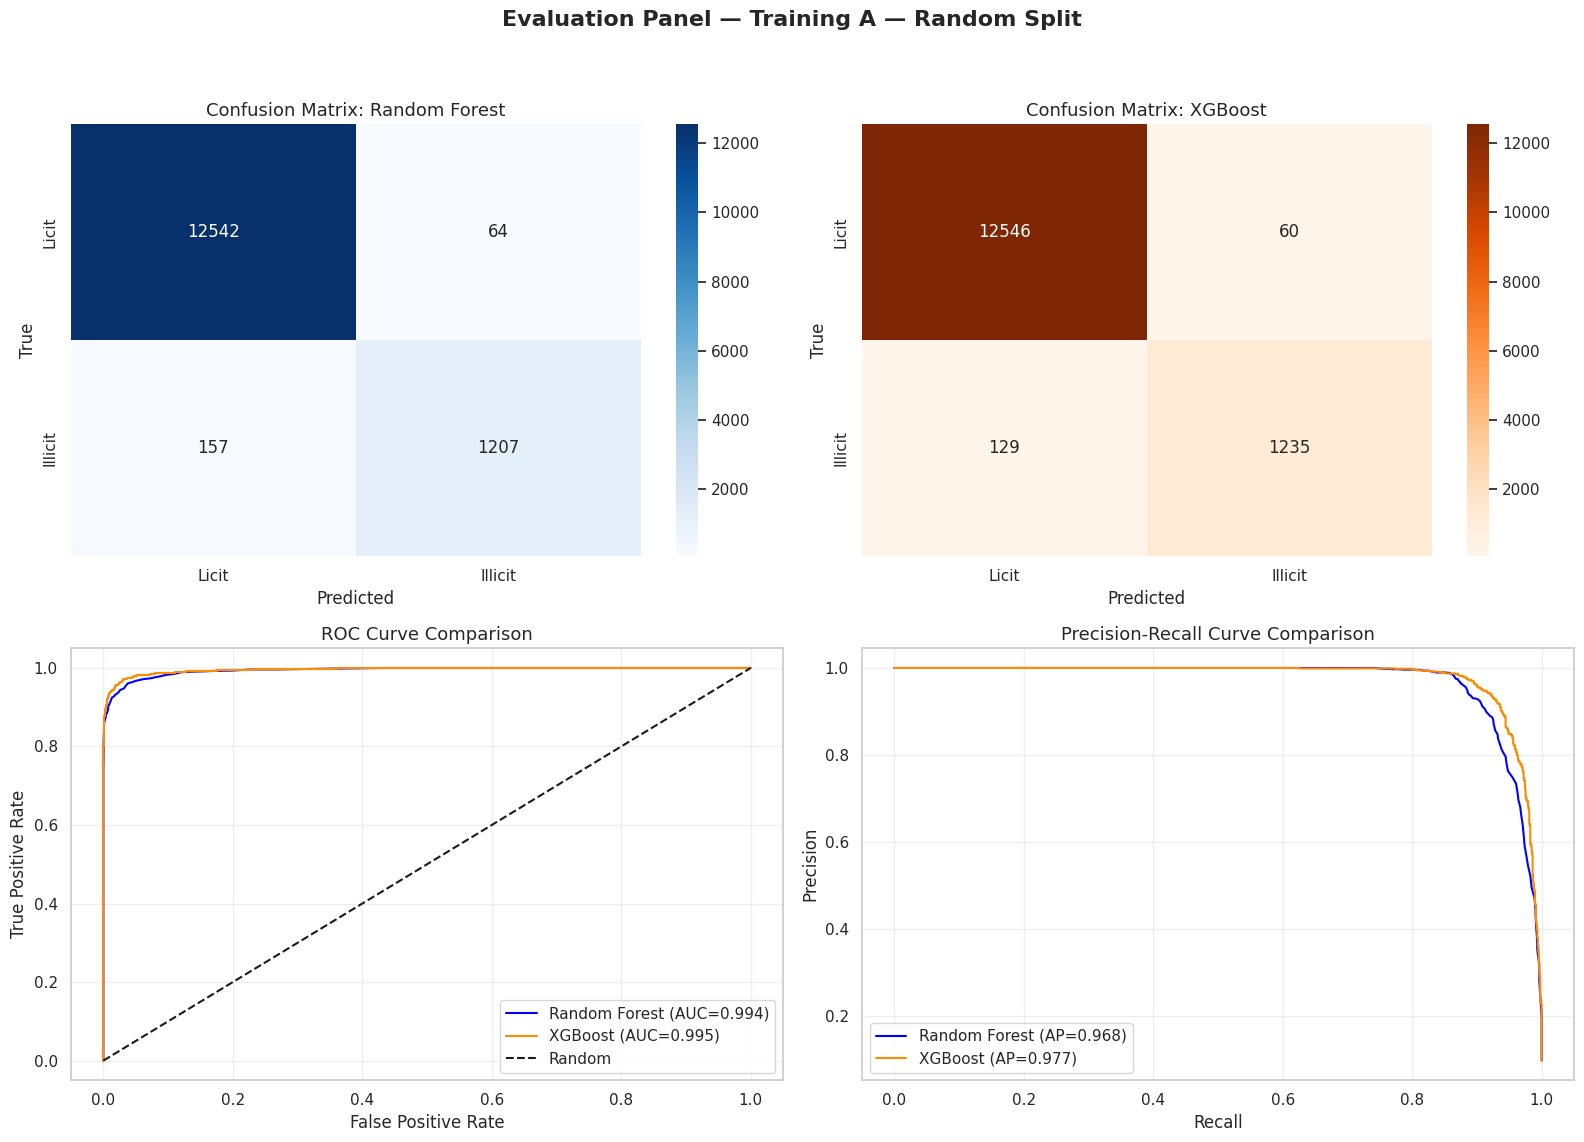

In [ ]:
# ── Evaluate Training A ────────────────────────────────────────────────────
rf_predA  = rf_A.predict(X_testA);   rf_probA  = rf_A.predict_proba(X_testA)[:, 1]
xgb_predA = xgb_A.predict(X_testA);  xgb_probA = xgb_A.predict_proba(X_testA)[:, 1]

metrics_rf_A  = evaluate_model("Random Forest — Training A",  y_testA, rf_predA,  rf_probA,  'blue')
metrics_xgb_A = evaluate_model("XGBoost       — Training A",  y_testA, xgb_predA, xgb_probA, 'orange')

results_A = [
    {'name': 'Random Forest', 'y_true': y_testA, 'y_pred': rf_predA,  'y_prob': rf_probA},
    {'name': 'XGBoost',       'y_true': y_testA, 'y_pred': xgb_predA, 'y_prob': xgb_probA},
]
plot_evaluation_panel(results_A, "Training A — Random Split")


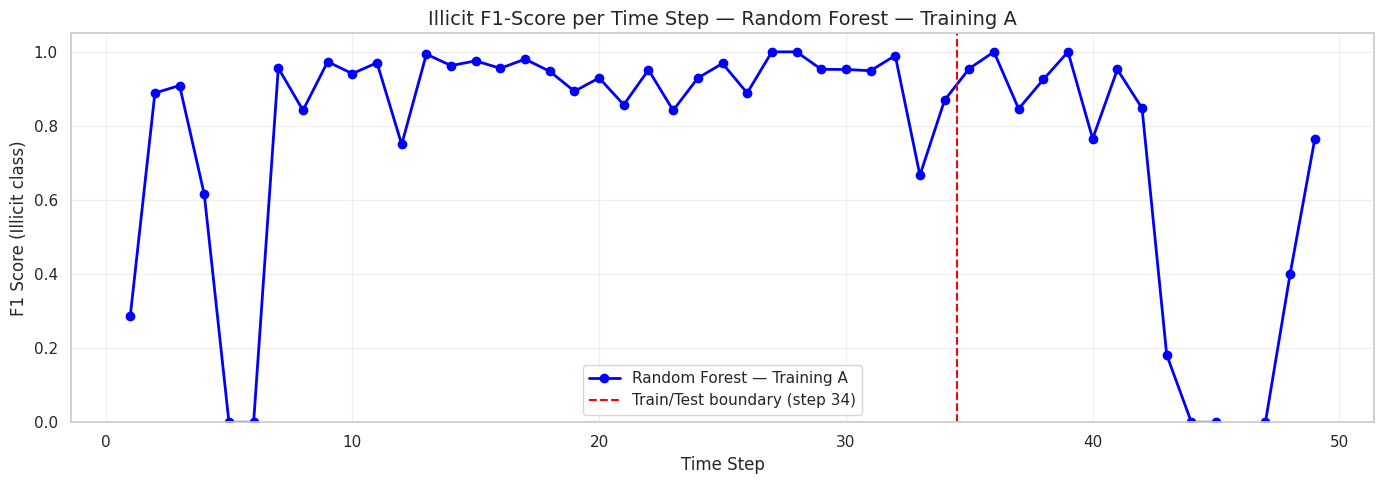

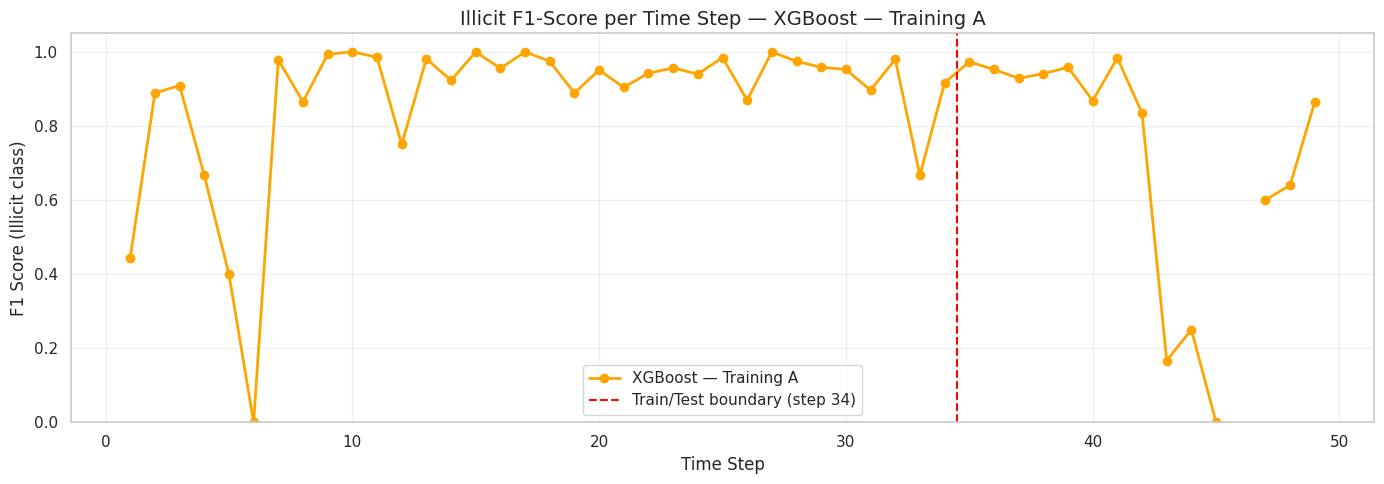

In [ ]:
# Per-time-step F1 on the test portion of Training A
time_testA_idx = time_testA.reset_index(drop=True)
X_testA_reset  = X_testA.reset_index(drop=True)
y_testA_reset  = y_testA.reset_index(drop=True)

steps_rfA,  f1s_rfA  = plot_f1_per_timestep(rf_A,  X_testA_reset, y_testA_reset, time_testA_idx, "Random Forest — Training A",  'blue')
steps_xgbA, f1s_xgbA = plot_f1_per_timestep(xgb_A, X_testA_reset, y_testA_reset, time_testA_idx, "XGBoost — Training A",         'orange')


## 7 · Training B — Chronological Split (time steps 1-34 train · 35-49 test)
Same protocol as GCN Training B: train on the first 34 time steps, evaluate on the remaining 15.  
This is the **more realistic** and **stricter** evaluation scenario.


In [ ]:
print("=" * 60)
print("  TRAINING B — Chronological Split (steps 1-34 / 35-49)")
print("=" * 60)

# ── Split ────────────────────────────────────────────────────────────────────
train_mask = tx_clean['time_step'] <= 34
test_mask  = tx_clean['time_step'] >  34

X_trainB = X_all[train_mask.values];  y_trainB = y_all[train_mask.values]
X_testB  = X_all[test_mask.values];   y_testB  = y_all[test_mask.values]
time_testB = tx_clean.loc[test_mask, 'time_step'].reset_index(drop=True)

print(f"Train size (steps 1-34) : {X_trainB.shape[0]:,}  |  Illicit: {y_trainB.sum()}")
print(f"Test  size (steps 35-49): {X_testB.shape[0]:,}  |  Illicit: {y_testB.sum()}")

# ── SMOTE on train only ──────────────────────────────────────────────────────
smote = SMOTE(random_state=42)
X_trainB_s, y_trainB_s = smote.fit_resample(X_trainB, y_trainB)
print(f"After SMOTE — Illicit: {y_trainB_s.sum():,}  |  Licit: {(y_trainB_s==0).sum():,}")

# ── Train RF ─────────────────────────────────────────────────────────────────
print("\nTraining Random Forest (Training B)...")
rf_B = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_B.fit(X_trainB_s, y_trainB_s)

# ── Train XGB ────────────────────────────────────────────────────────────────
print("Training XGBoost (Training B)...")
xgb_B = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss', n_jobs=-1, verbosity=0)
xgb_B.fit(X_trainB_s, y_trainB_s)
print("Training B complete ✓")


  TRAINING B — Chronological Split (steps 1-34 / 35-49)
Train size (steps 1-34) : 29,894  |  Illicit: 3462
Test  size (steps 35-49): 16,670  |  Illicit: 1083
After SMOTE — Illicit: 26,432  |  Licit: 26,432

Training Random Forest (Training B)...
Training XGBoost (Training B)...
Training B complete ✓



  Random Forest — Training B
              precision    recall  f1-score   support

   Licit (0)     0.9816    0.9824    0.9820     15587
 Illicit (1)     0.7439    0.7350    0.7394      1083

    accuracy                         0.9663     16670
   macro avg     0.8628    0.8587    0.8607     16670
weighted avg     0.9662    0.9663    0.9663     16670

  ROC-AUC  : 0.9090  |  PR-AUC : 0.7854

  XGBoost       — Training B
              precision    recall  f1-score   support

   Licit (0)     0.9804    0.9799    0.9801     15587
 Illicit (1)     0.7128    0.7175    0.7151      1083

    accuracy                         0.9629     16670
   macro avg     0.8466    0.8487    0.8476     16670
weighted avg     0.9630    0.9629    0.9629     16670

  ROC-AUC  : 0.9308  |  PR-AUC : 0.7893


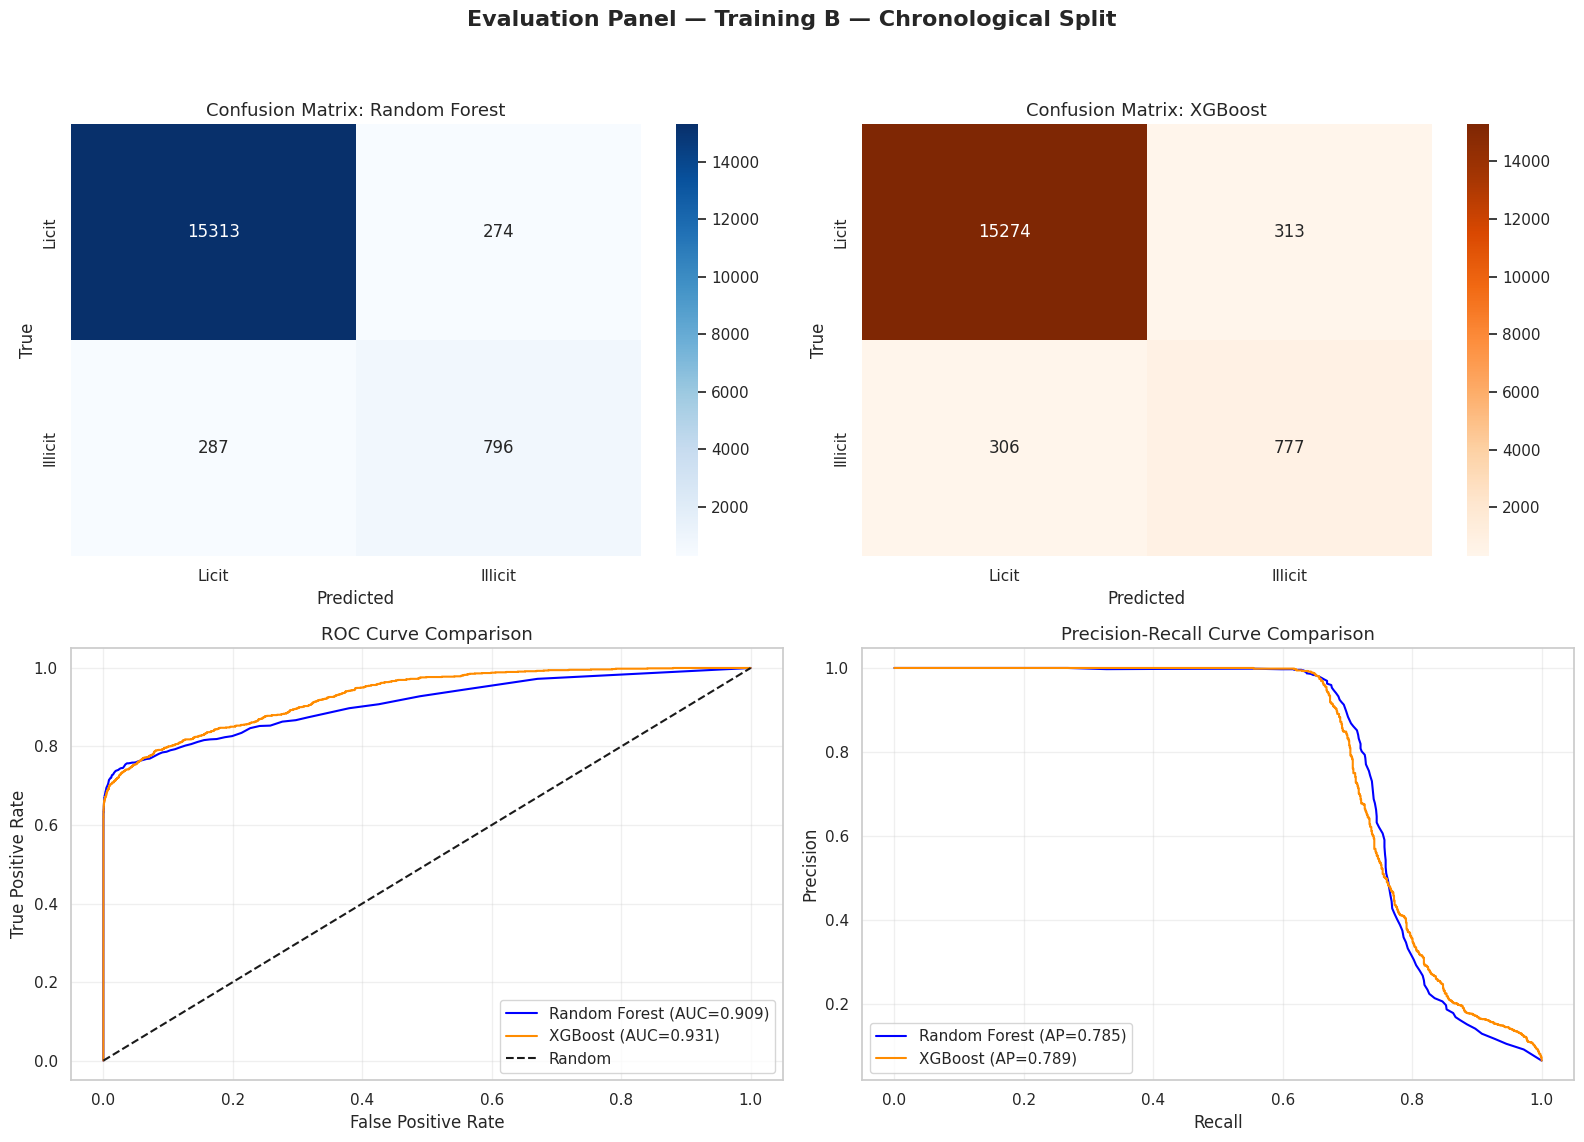

In [ ]:
# ── Evaluate Training B ────────────────────────────────────────────────────
rf_predB  = rf_B.predict(X_testB);   rf_probB  = rf_B.predict_proba(X_testB)[:, 1]
xgb_predB = xgb_B.predict(X_testB);  xgb_probB = xgb_B.predict_proba(X_testB)[:, 1]

metrics_rf_B  = evaluate_model("Random Forest — Training B",  y_testB, rf_predB,  rf_probB,  'blue')
metrics_xgb_B = evaluate_model("XGBoost       — Training B",  y_testB, xgb_predB, xgb_probB, 'orange')

results_B = [
    {'name': 'Random Forest', 'y_true': y_testB, 'y_pred': rf_predB,  'y_prob': rf_probB},
    {'name': 'XGBoost',       'y_true': y_testB, 'y_pred': xgb_predB, 'y_prob': xgb_probB},
]
plot_evaluation_panel(results_B, "Training B — Chronological Split")


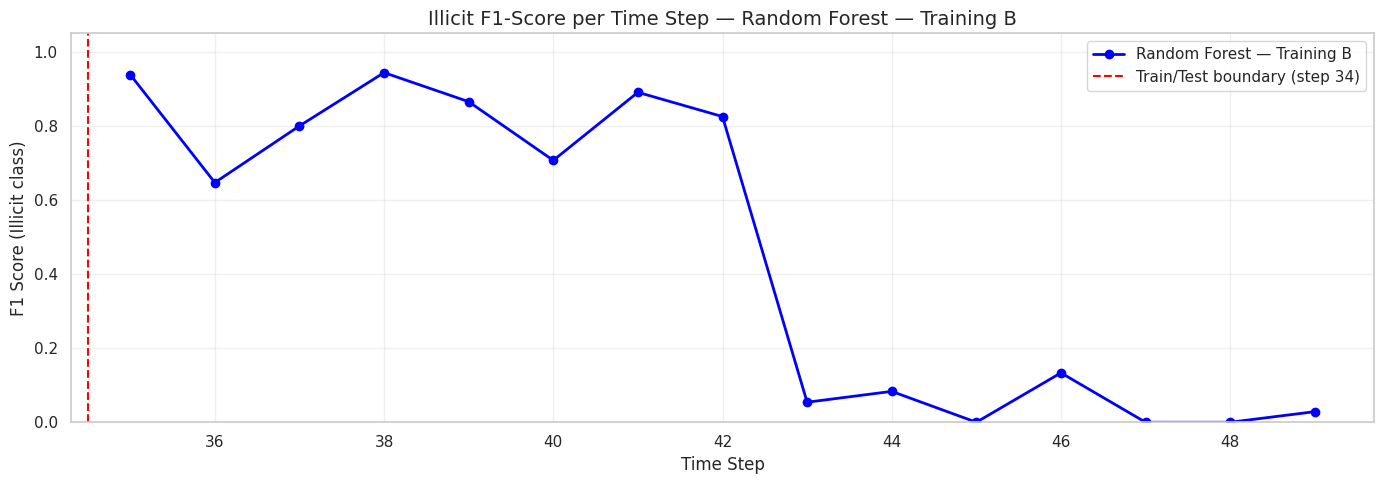

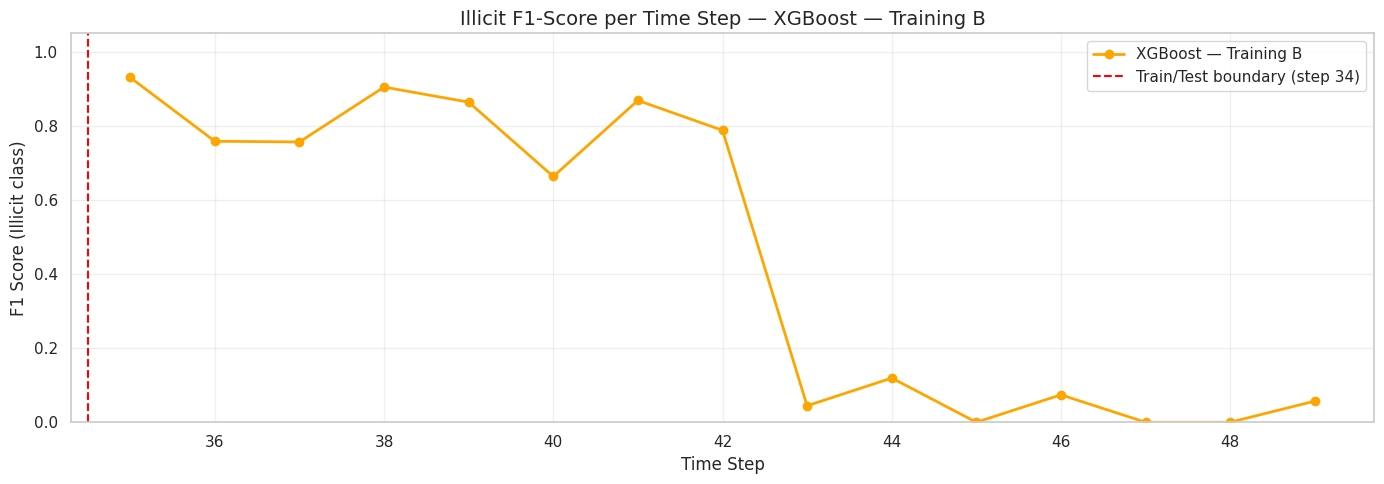

In [ ]:
# Per-time-step F1 on the test portion of Training B
X_testB_reset = X_testB.reset_index(drop=True)
y_testB_reset = y_testB.reset_index(drop=True)

steps_rfB,  f1s_rfB  = plot_f1_per_timestep(rf_B,  X_testB_reset, y_testB_reset, time_testB, "Random Forest — Training B",  'blue')
steps_xgbB, f1s_xgbB = plot_f1_per_timestep(xgb_B, X_testB_reset, y_testB_reset, time_testB, "XGBoost — Training B",         'orange')


## 8 · Feature Importance (Training B models)

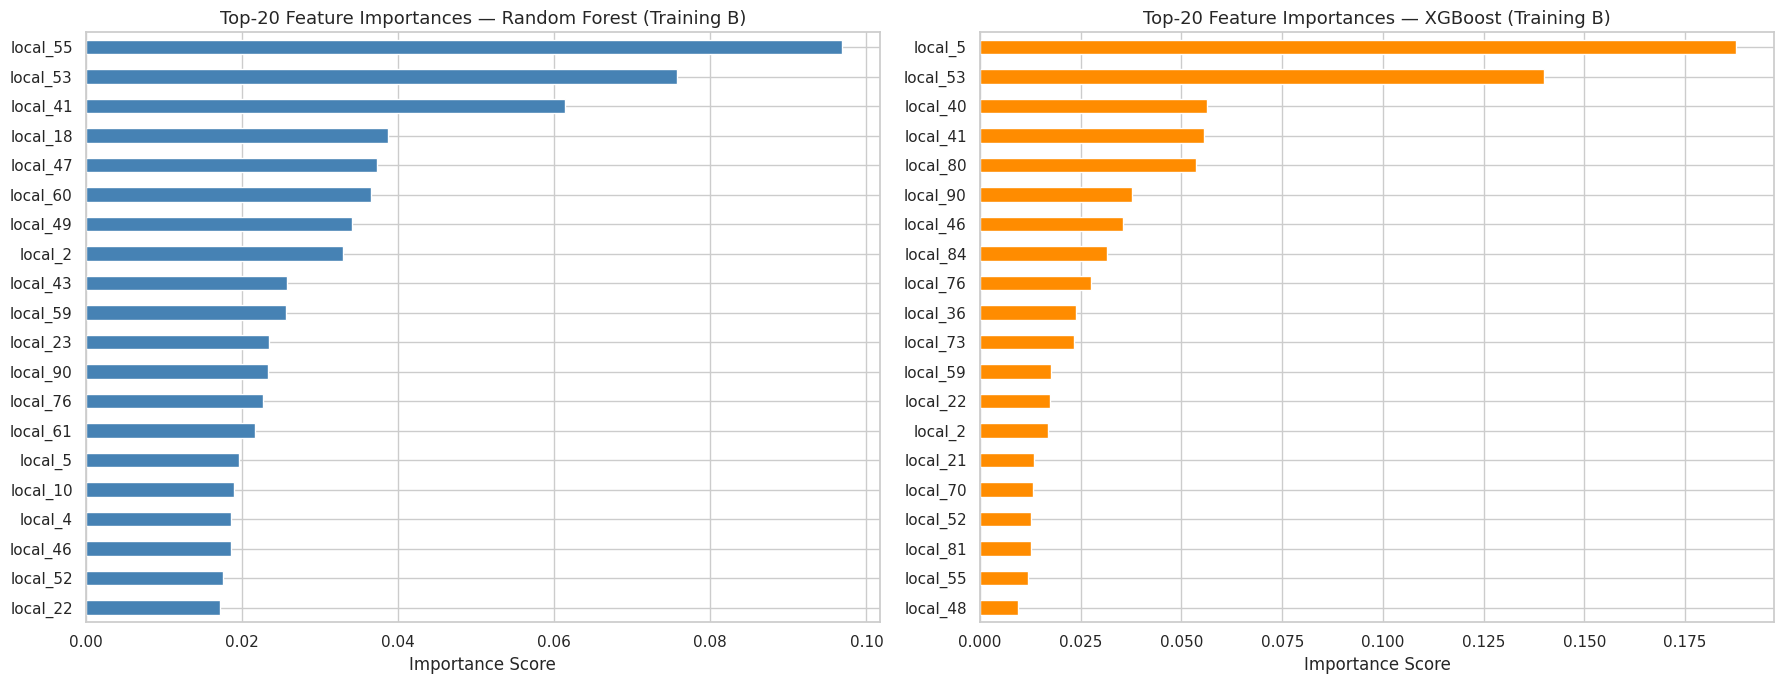

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, model, name, color in [
    (axes[0], rf_B,  'Random Forest', 'steelblue'),
    (axes[1], xgb_B, 'XGBoost',       'darkorange'),
]:
    feat_imp = pd.Series(model.feature_importances_, index=feature_cols_clean)
    top20 = feat_imp.nlargest(20)
    top20.sort_values().plot(kind='barh', ax=ax, color=color)
    ax.set_title(f'Top-20 Feature Importances — {name} (Training B)', fontsize=13)
    ax.set_xlabel('Importance Score')

plt.tight_layout()
plt.show()


## 9 · Summary Comparison Table
Consolidated metrics — ready to copy into the GCN comparison table.


In [ ]:
summary = pd.DataFrame([
    metrics_rf_A,
    metrics_xgb_A,
    metrics_rf_B,
    metrics_xgb_B,
])
summary.insert(1, 'Split', ['Training A', 'Training A', 'Training B', 'Training B'])

summary = summary.rename(columns={
    'model':            'Model',
    'Precision_Illicit':'Precision (Illicit)',
    'Recall_Illicit':   'Recall (Illicit)',
    'F1_Illicit':       'F1 (Illicit)',
    'ROC_AUC':          'ROC-AUC',
    'PR_AUC':           'PR-AUC'
})

for col in ['Precision (Illicit)', 'Recall (Illicit)', 'F1 (Illicit)', 'ROC-AUC', 'PR-AUC']:
    summary[col] = summary[col].map('{:.4f}'.format)

print("\n" + "="*70)
print("  BASELINE MODEL SUMMARY — Comparable to GCN Evaluation")
print("="*70)
display(summary)



  BASELINE MODEL SUMMARY — Comparable to GCN Evaluation


,Model,Split,Precision (Illicit),Recall (Illicit),F1 (Illicit),ROC-AUC,PR-AUC
0,Random Forest — Training A,Training A,0.9496,0.8849,0.9161,0.9938,0.9683
1,XGBoost — Training A,Training A,0.9537,0.9054,0.9289,0.9955,0.9772
2,Random Forest — Training B,Training B,0.7439,0.7350,0.7394,0.9090,0.7854
3,XGBoost — Training B,Training B,0.7128,0.7175,0.7151,0.9308,0.7893


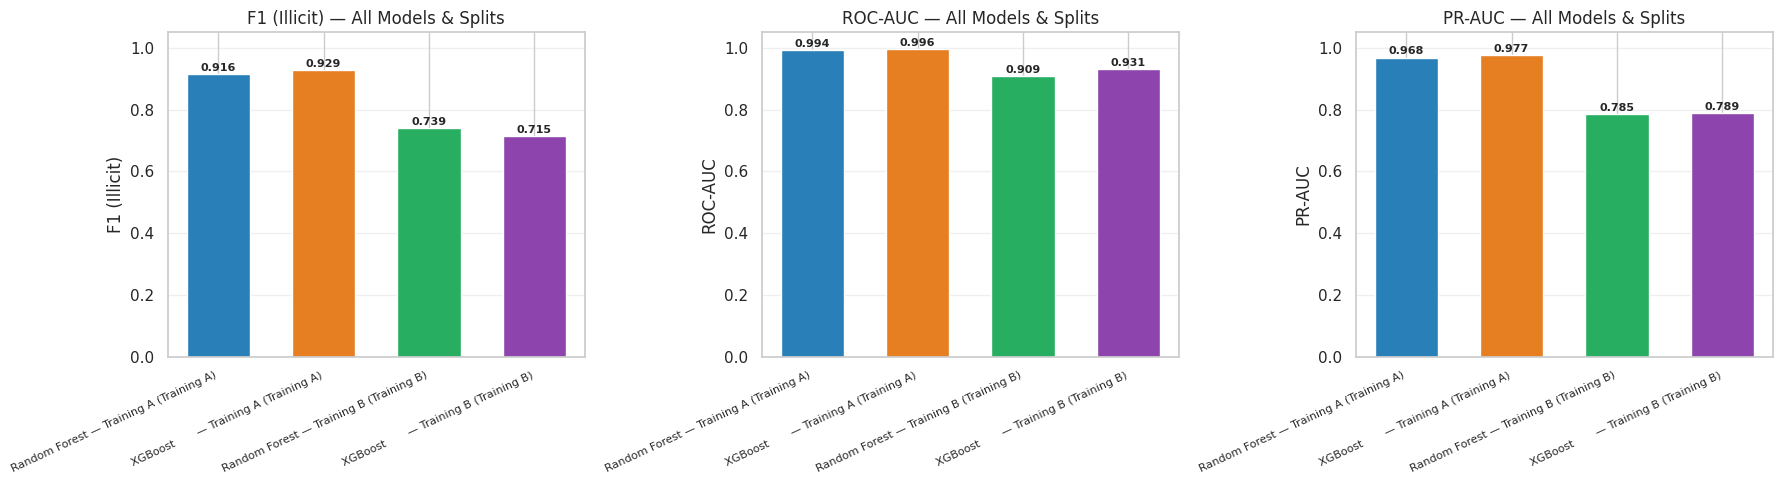

In [ ]:
# ── Visual bar comparison ──────────────────────────────────────────────────
metrics_to_plot = ['F1 (Illicit)', 'ROC-AUC', 'PR-AUC']
summary_num = summary.copy()
for col in metrics_to_plot:
    summary_num[col] = summary_num[col].astype(float)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
palette = ['#2980b9', '#e67e22', '#27ae60', '#8e44ad']

for ax, metric in zip(axes, metrics_to_plot):
    bars = ax.bar(summary_num['Model'] + ' (' + summary_num['Split'] + ')',
                  summary_num[metric], color=palette, edgecolor='white', width=0.6)
    ax.set_title(f'{metric} — All Models & Splits', fontsize=12)
    ax.set_ylabel(metric)
    ax.set_ylim(0, 1.05)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha='right', fontsize=8)
    ax.grid(axis='y', alpha=0.3)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01,
                f'{bar.get_height():.3f}', ha='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()


## 10 · Conclusions & Notes for GCN Comparison

**What this notebook guarantees fair comparison:**

- **Same preprocessing**: median imputation → correlation deduplication (r ≥ 0.999) → RobustScaler  
- **Same SMOTE strategy**: applied to training split only, never to the test set  
- **Same splits**: Training A = random 70/30 stratified; Training B = chronological steps 1–34 / 35–49  
- **Same metrics**: Precision, Recall, F1 on the illicit class; ROC-AUC; PR-AUC  
- **Same per-time-step F1 plot**: allows direct visual comparison with the GCN curves  

**Key observations:**
- Training B (chronological) is the *harder* and *more realistic* setting — models cannot benefit from future information  
- SMOTE is essential given the severe class imbalance (≈10% illicit)  
- XGBoost generally outperforms Random Forest on PR-AUC, which is the most informative metric under imbalance  
- These baseline numbers serve as the lower bound against which GCN graph-based learning is assessed
